In [2]:
import pandas as pd
import numpy as np
import geopandas
import folium
import geodatasets
import matplotlib.pyplot as plt
world = geopandas.read_file(geodatasets.get_path("naturalearth.land"))

In [9]:
df_power_plant = pd.read_csv('1_power_plant_database.csv', usecols=['country_long', 'fuel', 'latitude', 'longitude', 'capacity_mw'])
df_power_plant = df_power_plant.rename(columns={'country_long': 'country'})
print(df_power_plant.head())
print('')
print(df_power_plant['fuel'].unique())
print('')
df_hydro = df_power_plant[df_power_plant['fuel'].isin(['Hydro'])].drop(columns=['fuel'])
df_biomass = df_power_plant[df_power_plant['fuel'].isin(['Biomass'])].drop(columns=['fuel'])
# print(df_hydro.head())
# print(df_biomass.head())
# print('')
print(f"Number of Hydro: {len(df_hydro)}")
print(f"Number of Biomass: {len(df_biomass)}")
print('')
hydro_counts = df_hydro["country"].value_counts().reset_index()
hydro_counts.columns = ["country", "hydro_count"]
print(hydro_counts.head()[:3])
biomass_counts = df_biomass["country"].value_counts().reset_index()
biomass_counts.columns = ["country", "biomass_count"]
print(biomass_counts.head()[:3])

       country   fuel  latitude  longitude  capacity_mw
0  Afghanistan  Hydro    32.322    65.1190         33.0
1  Afghanistan  Solar    31.670    65.7950         10.0
2  Afghanistan  Solar    31.623    65.7920         10.0
3  Afghanistan  Hydro    34.556    69.4787         66.0
4  Afghanistan  Hydro    34.641    69.7170        100.0

['Hydro' 'Solar' 'Gas' 'Other' 'Oil' 'Wind' 'Nuclear' 'Coal' 'Waste'
 'Biomass' 'Wave and Tidal' 'Petcoke' 'Geothermal' 'Storage'
 'Cogeneration']

Number of Hydro: 7156
Number of Biomass: 1430

                    country  hydro_count
0  United States of America         1449
1                     China          947
2                    Brazil          701
                    country  biomass_count
0                    Brazil            444
1            United Kingdom            226
2  United States of America            153


In [11]:
df_ccs = pd.read_csv('2_ccs_database.csv')
df_ccs = df_ccs[df_ccs['status'].isin(['Hold', 'Terminated', 'Completed', 'Active'])]
df_ccs = df_ccs[['country', 'latitude', 'longitude', 'injection']]
print(df_ccs.head())
print('')
print(f"Number of CCS: {len(df_ccs)}")
# print('')
# missing = df_ccs[df_ccs['latitude'].isna() | df_ccs['longitude'].isna()]
# print(missing)
# print(f"Number of rows with missing latitude or longitude: {len(missing)}")
print('')
ccs_counts = df_ccs["country"].value_counts().reset_index()
ccs_counts.columns = ["country", "ccs_count"]
print(ccs_counts.head()[:3])

    country   latitude   longitude injection
36   Canada  53.945484 -113.067108   100,000
37  Germany  52.833680   11.154315   100,000
38   France  49.323907    6.091537     1,370
39    China  37.414200  118.607000     1,370
40   Norway  59.858580    5.740327     7,124

Number of CCS: 260

         country  ccs_count
0  United States        110
1      Australia         24
2         Canada         19


In [5]:
df_smr = pd.read_csv('3_smr_database.csv', usecols=['country', 'latitude', 'longitude', 'capacity_mw'])
print(df_smr.head())

   country   latitude  longitude  capacity_mw
0  Russian  57.000000  160.00000           70
1    China  36.972222  122.52889          400


In [12]:
df_hydrogen = pd.read_csv('4_hydrogen_database.csv', encoding='latin1')
df_hydrogen = df_hydrogen[df_hydrogen['status'].isin(['Operational', 'DEMO', 'Decommisioned'])]
df_hydrogen = df_hydrogen[['country', 'latitude', 'longitude', 'capacity_MWel']]
print(df_hydrogen.head())
print('')
print(f"Number of Hydrogen: {len(df_hydrogen)}")
# print('')
# missing = df_hydrogen[df_hydrogen['latitude'].isna() | df_hydrogen['longitude'].isna()]
# print(missing)
# print(f"Number of rows with missing latitude or longitude: {len(missing)}")
print('')
hydrogen_counts = df_hydrogen["country"].value_counts().reset_index()
hydrogen_counts.columns = ["country", "hydrogen_count"]
print(hydrogen_counts.head()[:3])

   country   latitude   longitude  capacity_MWel
5      SWE  65.585456   22.157661            4.5
7      ESP  38.672067   -4.053051           20.0
8      ESP  39.718519    2.869602            2.5
10     USA  39.818347 -105.090850            1.0
11     JPN  37.416487  140.516114           10.0

Number of Hydrogen: 586

  country  hydrogen_count
0     DEU              99
1     USA              57
2     FRA              40


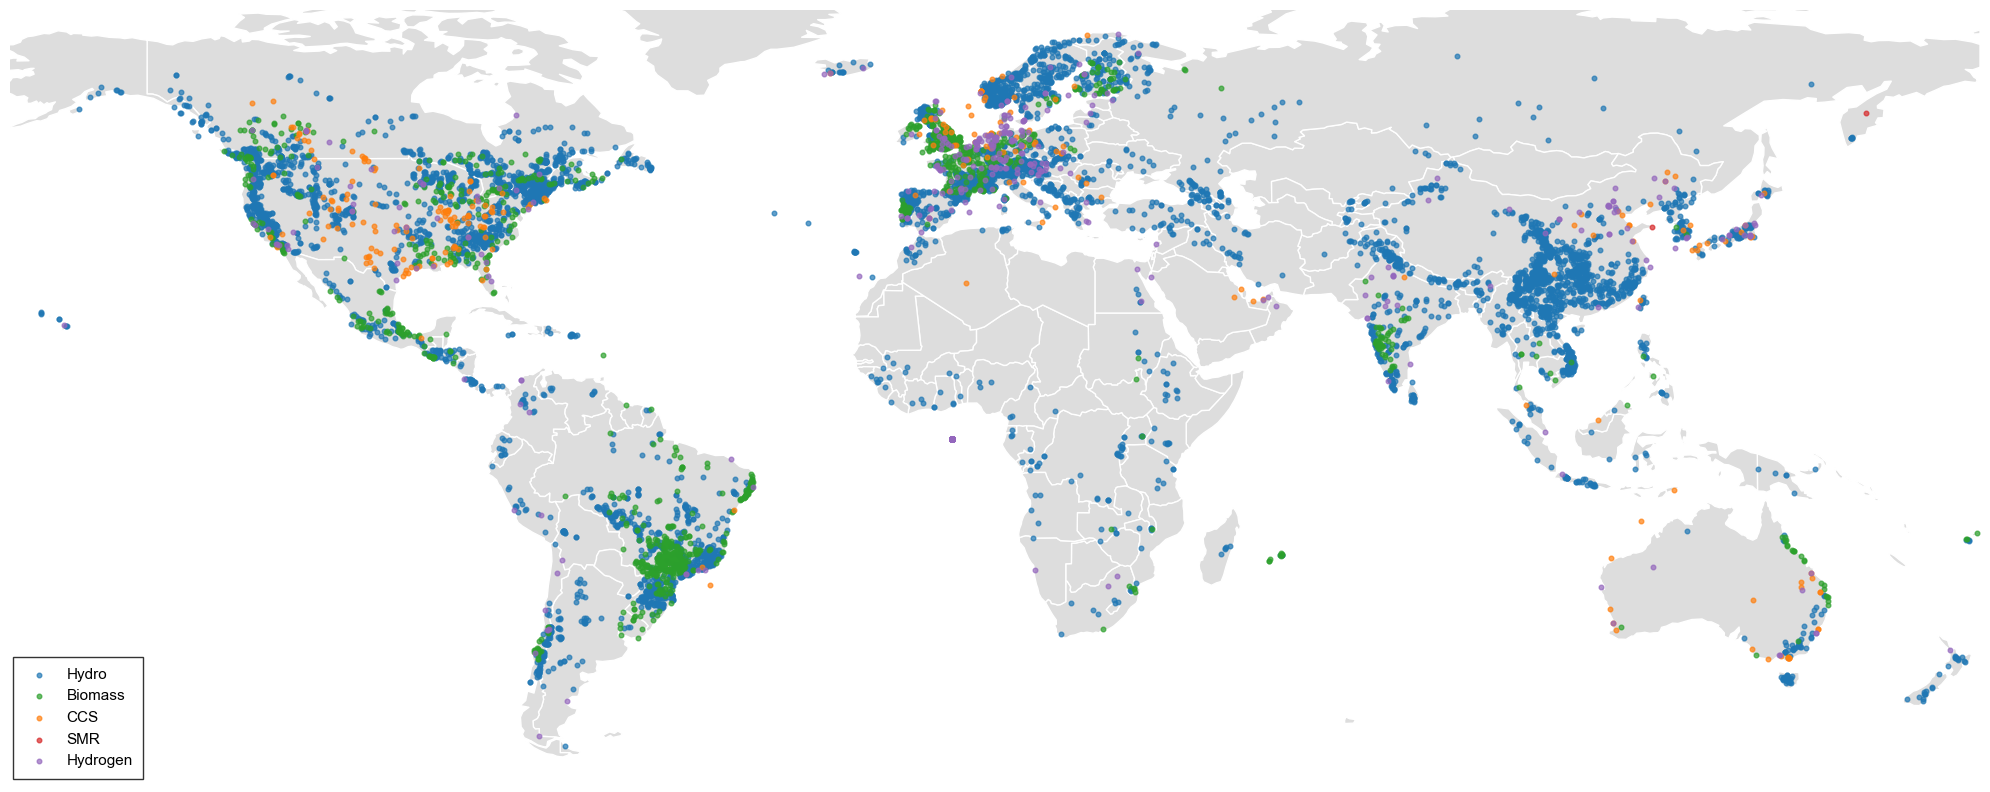

In [23]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

# ——— 1. load world map ———
world_url = (
    "https://raw.githubusercontent.com/"
    "nvkelso/natural-earth-vector/master/geojson/"
    "ne_110m_admin_0_countries.geojson"
)
world = gpd.read_file(world_url)

# ——— 2. plot ———
fig, ax = plt.subplots(figsize=(20, 10))

# Background map: gray fill, white border
world.plot(ax=ax, color='#dddddd', edgecolor='white')

# Customize color mapping for each category
category_colors = {
    'df_hydro': '#1f77b4',     # blue
    'df_biomass': '#2ca02c',   # green
    'df_ccs': '#ff7f0e',       # orange
    'df_smr': '#d62728',       # red
    'df_hydrogen': '#9467bd'   # purple
}

# Plot each category
size = 11
alpha = 0.7
ax.scatter(df_hydro['longitude'], df_hydro['latitude'], s=size, c=category_colors['df_hydro'], label='Hydro', alpha=alpha)
ax.scatter(df_biomass['longitude'], df_biomass['latitude'], s=size, c=category_colors['df_biomass'], label='Biomass', alpha=alpha)
ax.scatter(df_ccs['longitude'], df_ccs['latitude'], s=size, c=category_colors['df_ccs'], label='CCS', alpha=alpha)
ax.scatter(df_smr['longitude'], df_smr['latitude'], s=size, c=category_colors['df_smr'], label='SMR', alpha=alpha)
ax.scatter(df_hydrogen['longitude'], df_hydrogen['latitude'], s=size, c=category_colors['df_hydrogen'], label='Hydrogen', alpha=alpha)

# Set limits and labels
ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)
ax.set_xticks([]) 
ax.set_yticks([]) 
# ax.set_xlabel('Longitude (°)')
# ax.set_ylabel('Latitude (°)')
leg = ax.legend(loc='lower left', fontsize=11)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_boxstyle('square')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('global_deployment.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [14]:
df_storage = pd.read_csv('5_storage_database.csv')
df_storage = df_storage[df_storage['status'].isin(['Operational', 'Offline/Under Repair', 'De-Commissioned', 'Under Construction'])]
df_storage = df_storage[['technology', 'rated power_kW', 'country', 'latitude', 'longitude']]
df_storage = df_storage[df_storage['technology'].notna()]
print(df_storage.head())
print('')
print(f"Number of Storage: {len(df_storage)}")
# print('')
# missing = df_storage[df_storage['latitude'].isna() | df_storage['longitude'].isna()]
# print(missing)
# print(f"Number of rows with missing latitude or longitude: {len(missing)}")
print('')
storage_counts = df_storage["country"].value_counts().reset_index()
storage_counts.columns = ["country", "storage_count"]
print(storage_counts.head()[:3])
print('')
print(df_storage['technology'].unique())
print('')
# Define mapping from specific technology to category
tech_category_map = {
    # Mechanical Storage
    'Pumped hydro storage': 'Mechanical storage',
    'Compressed air energy storage': 'Mechanical storage',
    'Flywheel': 'Mechanical storage',
    # Electrochemical Storage (Batteries & Capacitors)
    'Lithium-ion battery': 'Electrochemical storage',
    'Lead-acid battery': 'Electrochemical storage',
    'Sodium-based battery': 'Electrochemical storage',
    'Flow battery': 'Electrochemical storage',
    'Nickel-based battery': 'Electrochemical storage',
    'Electro-chemical capacitor': 'Electrochemical storage',
    # Thermal Storage
    'Sensible heat': 'Thermal storage',
    'Latent heat': 'Thermal storage',
    'Heat thermal storage': 'Thermal storage',
    # Chemical Storage
    'Hydrogen storage': 'Chemical storage'
}

# Map the technology column to the new category
df_storage['category'] = df_storage['technology'].map(tech_category_map)

print(df_storage[['technology', 'category']].head())

             technology  rated power_kW        country   latitude  longitude
0  Pumped hydro storage           80000          Italy  45.888517      10.84
1  Pumped hydro storage            7200          Spain  42.633421       0.22
2  Pumped hydro storage           29000  United States  41.582580     -73.43
3  Pumped hydro storage          135000    Switzerland  47.136963       8.78
4  Pumped hydro storage           30000         Russia  55.850657      37.44

Number of Storage: 1411

         country  storage_count
0  United States            570
1          China             93
2          Japan             88

['Pumped hydro storage' 'Flywheel' 'Compressed air energy storage'
 'Sensible heat' 'Lead-acid battery' 'Latent heat' 'Sodium-based battery'
 'Flow battery' 'Hydrogen storage' 'Lithium-ion battery'
 'Electro-chemical capacitor' 'Heat thermal storage'
 'Nickel-based battery']

             technology            category
0  Pumped hydro storage  Mechanical storage
1  Pumped hydro st

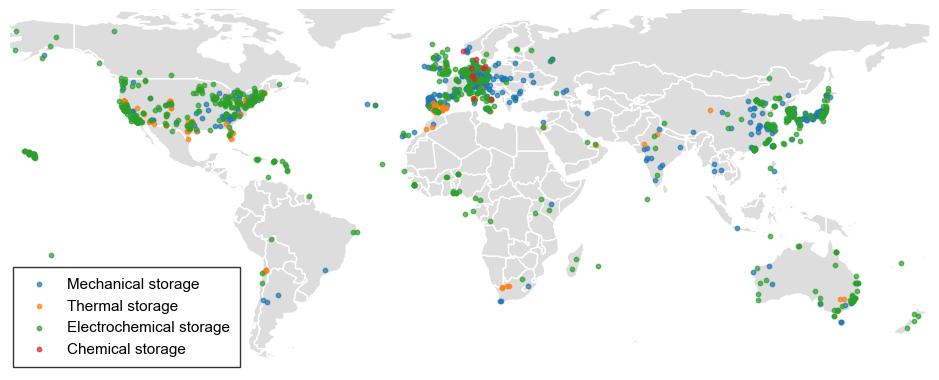

In [24]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(9.5, 10))
world.plot(ax=ax, color='#dddddd', edgecolor='white')

# Get unique categories and assign a color to each
categories = df_storage['category'].unique()
colors = plt.cm.tab10.colors  # Up to 10 distinct colors
color_map = {cat: colors[i % len(colors)] for i, cat in enumerate(categories)}

# Plot each category
for cat in categories:
    subset = df_storage[df_storage['category'] == cat]
    ax.scatter(subset['longitude'], subset['latitude'],
               s=10, c=[color_map[cat]], label=cat, alpha=0.7)

ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)
ax.set_xticks([]) 
ax.set_yticks([]) 
leg = ax.legend(loc='lower left', fontsize=11)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_boxstyle('square')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('storage_deployment.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [16]:
df_gas = pd.read_csv('6_gas_infrastructure_database.csv')
df_gas = df_gas[df_gas['status'].isin(['Operating', 'Idle', 'Mothballed', 'Shelved', 'Retired'])]
df_gas = df_gas[['type', 'country', 'Capacity', 'latitude', 'longitude']]
print(df_gas.head())
print('')
print(f"Number of Gas Infrastructure: {len(df_gas)}")
print('')
missing = df_gas[df_gas['latitude'].isna() | df_gas['longitude'].isna()]
# print(missing)
# print(f"Number of rows with missing latitude or longitude: {len(missing)}")
# print('')
print(df_gas['type'].unique())
print('')
gas_counts = df_gas["country"].value_counts().reset_index()
gas_counts.columns = ["country", "gas_count"]
print(gas_counts.head()[:3])

      type        country  Capacity   latitude  longitude
6   Export  United States      0.01  25.809175 -80.296697
14  Export  United States      0.67  29.772927 -93.334304
15  Export  United States      0.67  29.772927 -93.334304
16  Export  United States      0.67  29.772927 -93.334304
17  Export  United States      0.67  29.772927 -93.334304

Number of Gas Infrastructure: 523

['Export' 'Import']

         country  gas_count
0  United States         61
1          China         60
2          Japan         46


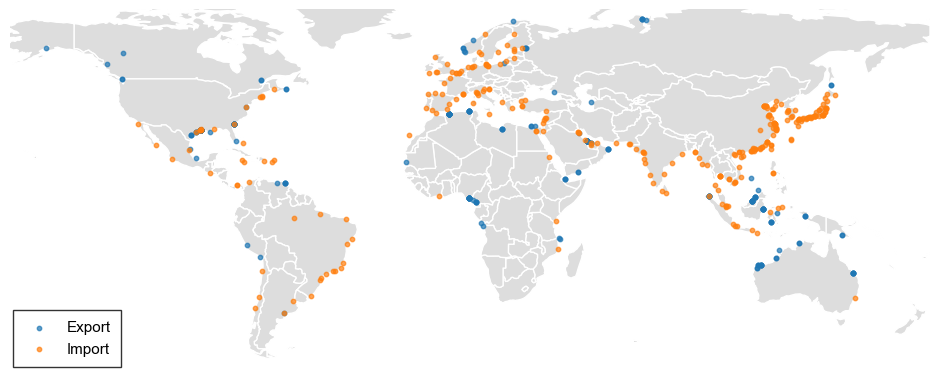

In [25]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(9.5, 10))
world.plot(ax=ax, color='#dddddd', edgecolor='white')

# Get unique types and assign a color to each
types = df_gas['type'].unique()
colors = plt.cm.tab10.colors  # Up to 10 distinct colors
color_map = {cat: colors[i % len(colors)] for i, cat in enumerate(types)}

# Plot each type
for cat in types:
    subset = df_gas[df_gas['type'] == cat]
    ax.scatter(subset['longitude'], subset['latitude'],
               s=10, c=[color_map[cat]], label=cat, alpha=0.7)

ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)
ax.set_xticks([]) 
ax.set_yticks([]) 
leg = ax.legend(loc='lower left', fontsize=11)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_boxstyle('square')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('gas_deployment.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [27]:
df_interconnector = pd.read_csv('7_interconnector_database.csv')
#print(df_interconnector['time'].unique())
#df_interconnector = df_interconnector[df_interconnector['time'] == 2024]
print(df_interconnector.head())
print('')
print(f"Number of Interconnectors: {len(df_interconnector)}")
print('')

import difflib

# Extract country lists
world_countries = world["NAME"].unique().tolist()
csv_countries = df_interconnector["country"].dropna().unique().tolist()
# Build fuzzy-matched mapping using difflib
mapping = {}
for c in csv_countries:
    match = difflib.get_close_matches(c, world_countries, n=1, cutoff=0.9) 
    mapping[c] = match[0] if match else None

# Put mapping into a DataFrame
mapping_df = pd.DataFrame(list(mapping.items()), columns=["CSV_country", "Matched_NAME"])
mapping_df["Similarity"] = mapping_df.apply(
    lambda row: difflib.SequenceMatcher(None, row["CSV_country"], str(row["Matched_NAME"])).ratio(), axis=1
).round(2)

#mapping_df.sort_values("Similarity", ascending=False)[-21:]
df_sorted = df_interconnector.sort_values("Net imports - TWh",ascending=False)
# plt.figure(figsize=(20, 3))
# plt.bar(df_sorted["country"], df_sorted["market_share_2024 (%)"])
print(df_sorted[["country", "Net imports - TWh"]][:3])
print(df_sorted[["country", "Net imports - TWh"]][-3:])

          country Unnamed: 1  Net imports - TWh  time
0           Italy        NaN              50.94  2024
1        Thailand        NaN              37.08  2024
2  United Kingdom        NaN              33.19  2024
3         Germany        NaN              25.45  2024
4          Brazil        NaN              15.11  2024

Number of Interconnectors: 189

          country  Net imports - TWh
0           Italy              50.94
1        Thailand              37.08
2  United Kingdom              33.19
    country  Net imports - TWh
186  Sweden             -33.47
187    Laos             -37.04
188  France             -91.02


C:\Users\Dawei Qiu\AppData\Local\Temp\ipykernel_2384\3221057277.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


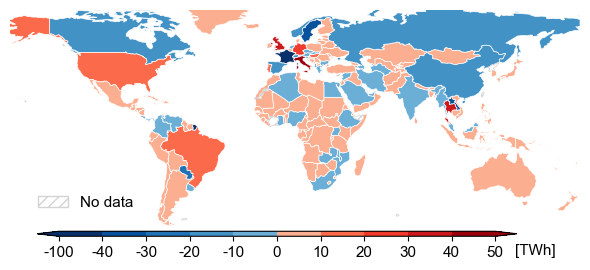

In [113]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

# Prepare and merge data
world_merged = world.merge(df_interconnector, how='left', left_on='NAME', right_on='country')

# --- 1. Define custom bounds ---
bounds = [-100, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50]  # cover full range
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=10)

# --- 2. Define custom colors (10 categories) ---
custom_colors = [
    "#08306b", "#08519c", "#2171b5", "#4292c6", "#6baed6",
    "#fcae91", "#fb6a4a", "#ef3b2c", "#cb181d", "#99000d"
]
cmap = mcolors.ListedColormap(custom_colors)

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
world_merged.plot(
    column='Net imports - TWh',
    cmap=cmap,
    norm=norm,
    linewidth=0.5,
    ax=ax,
    edgecolor='white',
    legend=False,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///"
    }
)

# Remove axes
ax.set_axis_off()
ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)

# --- 4. Add discrete colorbar ---
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.07, 0.27, 0.8, 0.01])  # [left, bottom, width, height] in figure coordinates
cbar = fig.colorbar(
    sm,
    cax=cbar_ax,  # use the custom axes
    orientation="horizontal",
    fraction=0.15,
    pad=0.0,
    shrink=0.8, 
    aspect=80, 
    extend='both',
    boundaries=bounds,
    ticks=[-100,-40, -30, -20, -10, 0, 10, 20, 30, 40, 50]
)

# Format ticks with TWh
tick_labels = ["-100", "-40", "-30", "-20", "-10", "0", "10", "20", "30", "40", "50"]
cbar.ax.set_xticklabels(tick_labels, fontsize=11)

# --- 5. Add "No data" patch to the left of colorbar ---
no_data_patch = Patch(facecolor="white", edgecolor="lightgrey", hatch="///", label="No data")
cbar.ax.legend(
    handles=[no_data_patch],
    loc="lower left",
    bbox_to_anchor=(-0.08, 2.5),
    frameon=False,
    fontsize=11
)

# Add custom text "[%]" below the colorbar
fig.text(
    0.90,         # x position (0 to 1, relative to figure width)
    0.242,         # y position (0 to 1, relative to figure height)
    "[TWh]",      # text to display
    ha='center', # horizontal alignment
    va='center', # vertical alignment
    fontsize=11, 
    fontname='Arial', 
)

plt.tight_layout()
plt.savefig('interconnector_deployment.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [114]:
df_appliance = pd.read_csv('8_smart_appliance_database.csv')
# Compute market share
df_appliance["market_share_2024"] = df_appliance["revenue_2024"] / df_appliance["revenue_2024"].sum()
# Convert to percentage if needed
df_appliance["market_share_2024 (%)"] = df_appliance["market_share_2024"] * 100
# Preview
print(df_appliance.head())
print('')
print(f"Number of Appliances: {len(df_appliance)}")
print('')

import difflib
# Extract country lists
world_countries = world["NAME"].unique().tolist()
csv_countries = df_appliance["country"].dropna().unique().tolist()
# Build fuzzy-matched mapping using difflib
mapping = {}
for c in csv_countries:
    match = difflib.get_close_matches(c, world_countries, n=1, cutoff=0.9) 
    mapping[c] = match[0] if match else None

# Put mapping into a DataFrame
mapping_df = pd.DataFrame(list(mapping.items()), columns=["CSV_country", "Matched_NAME"])
mapping_df["Similarity"] = mapping_df.apply(
    lambda row: difflib.SequenceMatcher(None, row["CSV_country"], str(row["Matched_NAME"])).ratio(), axis=1
).round(2)

#mapping_df.sort_values("Similarity", ascending=False)[-5:]
df_sorted = df_appliance.sort_values("market_share_2024 (%)",ascending=False)
# plt.figure(figsize=(20, 3))
# plt.bar(df_sorted["country"], df_sorted["market_share_2024 (%)"])
print(df_sorted[["country", "market_share_2024 (%)"]][:3])

                    country  revenue_2024     share          sum  \
0                     China  1.703511e+10  28.0891%  60646766609   
1  United States of America  1.124908e+10  18.5485%  60646766609   
2                     Japan  3.884933e+09   6.4058%  60646766609   
3               South Korea  3.511996e+09   5.7909%  60646766609   
4            United Kingdom  3.107465e+09   5.1239%  60646766609   

   market_share_2024  market_share_2024 (%)  
0           0.280891              28.089063  
1           0.185485              18.548530  
2           0.064058               6.405837  
3           0.057909               5.790905  
4           0.051239               5.123875  

Number of Appliances: 151

                    country  market_share_2024 (%)
0                     China              28.089063
1  United States of America              18.548530
2                     Japan               6.405837


C:\Users\Dawei Qiu\AppData\Local\Temp\ipykernel_2384\4169365801.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


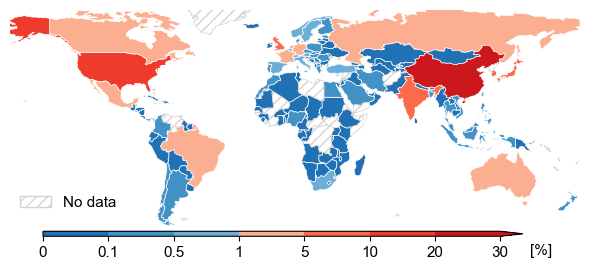

In [126]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

# Prepare and merge data
world_merged = world.merge(df_appliance, how='left', left_on='NAME', right_on='country')

# --- 1. Define custom bounds ---
bounds = [0, 0.1, 0.5, 1, 5, 10, 20, 30]  # cover full range
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=7)

# --- 2. Define custom colors (8 categories) ---
custom_colors = [
    "#2171b5", "#4292c6", "#6baed6",
    "#fcae91", "#fb6a4a", "#ef3b2c", "#cb181d"
]
cmap = mcolors.ListedColormap(custom_colors)

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
world_merged.plot(
    column='market_share_2024 (%)',
    cmap=cmap,
    norm=norm,
    linewidth=0.5,
    ax=ax,
    edgecolor='white',
    legend=False,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///"
    }
)

# Remove axes
ax.set_axis_off()
ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)

# --- 4. Add discrete colorbar ---
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.08, 0.27, 0.8, 0.01])  # [left, bottom, width, height] in figure coordinates
cbar = fig.colorbar(
    sm,
    cax=cbar_ax,  # use the custom axes
    orientation="horizontal",
    fraction=0.1,
    pad=0.0,
    shrink=0.95, 
    aspect=80, 
    extend='max',
    boundaries=bounds,
    ticks=[0, 0.1, 0.5, 1, 5, 10, 20, 30]
)

# Format ticks with TWh
tick_labels = ["0", "0.1", "0.5", "1", "5", "10", "20", "30"]
cbar.ax.set_xticklabels(tick_labels, fontsize=11)

# --- 5. Add "No data" patch to the left of colorbar ---
no_data_patch = Patch(facecolor="white", edgecolor="lightgrey", hatch="///", label="No data")
cbar.ax.legend(
    handles=[no_data_patch],
    loc="lower left",
    bbox_to_anchor=(-0.08, 2.5),
    frameon=False,
    fontsize=11
)

# Add custom text "[%]" below the colorbar
fig.text(
    0.91,         # x position (0 to 1, relative to figure width)
    0.242,         # y position (0 to 1, relative to figure height)
    "[%]",      # text to display
    ha='center', # horizontal alignment
    va='center', # vertical alignment
    fontsize=11, 
    fontname='Arial', 
)

plt.tight_layout()
plt.savefig('appliance_deployment.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [127]:
df_data_center = pd.read_csv('9_data_center_database.csv')
# Preview
print(df_data_center.head())
print('')
print(f"Number of Data Centers: {len(df_data_center)}")
print('')

import difflib
# Extract country lists
world_countries = world["NAME"].unique().tolist()
csv_countries = df_data_center["country"].dropna().unique().tolist()
# Build fuzzy-matched mapping using difflib
mapping = {}
for c in csv_countries:
    match = difflib.get_close_matches(c, world_countries, n=1, cutoff=0.9) 
    mapping[c] = match[0] if match else None

# Put mapping into a DataFrame
mapping_df = pd.DataFrame(list(mapping.items()), columns=["CSV_country", "Matched_NAME"])
mapping_df["Similarity"] = mapping_df.apply(
    lambda row: difflib.SequenceMatcher(None, row["CSV_country"], str(row["Matched_NAME"])).ratio(), axis=1
).round(2)

#mapping_df.sort_values("Similarity", ascending=False)[-25:]
df_sorted = df_data_center.sort_values("numbers",ascending=False)
# plt.figure(figsize=(20, 3))
# plt.bar(df_sorted["country"], df_sorted["numbers"])
print(df_sorted[["country", "numbers"]][:3])

                    country  numbers
0  United States of America     4025
1            United Kingdom      484
2                   Germany      480
3                     China      474
4                    France      313

Number of Data Centers: 169

                    country  numbers
0  United States of America     4025
1            United Kingdom      484
2                   Germany      480


C:\Users\Dawei Qiu\AppData\Local\Temp\ipykernel_2384\164477372.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


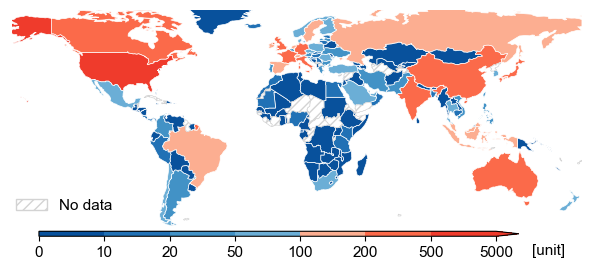

In [131]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

# Prepare and merge data
world_merged = world.merge(df_data_center, how='left', left_on='NAME', right_on='country')

# --- 1. Define custom bounds ---
bounds = [0, 10, 20, 50, 100, 200, 500, 5000]  # cover full range
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=7)

# --- 2. Define custom colors (8 categories) ---
custom_colors = [
    "#08519c", "#2171b5", "#4292c6", "#6baed6",
    "#fcae91", "#fb6a4a", "#ef3b2c",
]
cmap = mcolors.ListedColormap(custom_colors)

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
world_merged.plot(
    column='numbers',
    cmap=cmap,
    norm=norm,
    linewidth=0.5,
    ax=ax,
    edgecolor='white',
    legend=False,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///"
    }
)

# Remove axes
ax.set_axis_off()
ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)

# --- 4. Add discrete colorbar ---
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.07, 0.27, 0.8, 0.01])  # [left, bottom, width, height] in figure coordinates
cbar = fig.colorbar(
    sm,
    cax=cbar_ax,  # use the custom axes
    orientation="horizontal",
    fraction=0.1,
    pad=0.0,
    shrink=0.95, 
    aspect=80, 
    extend='max',
    boundaries=bounds,
    ticks=[0, 10, 20, 50, 100, 200, 500, 5000]
)

# Format ticks with TWh
tick_labels = ["0", "10", "20", "50", "100", "200", "500", "5000"]
cbar.ax.set_xticklabels(tick_labels, fontsize=11)

# --- 5. Add "No data" patch to the left of colorbar ---
no_data_patch = Patch(facecolor="white", edgecolor="lightgrey", hatch="///", label="No data")
cbar.ax.legend(
    handles=[no_data_patch],
    loc="lower left",
    bbox_to_anchor=(-0.08, 2.0),
    frameon=False,
    fontsize=11
)

# Add custom text "[%]" below the colorbar
fig.text(
    0.92,         # x position (0 to 1, relative to figure width)
    0.242,         # y position (0 to 1, relative to figure height)
    "[unit]",      # text to display
    ha='center', # horizontal alignment
    va='center', # vertical alignment
    fontsize=11, 
    fontname='Arial', 
)

plt.tight_layout()
plt.savefig('data_center_deployment.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [28]:
df_cs = pd.read_csv('10_charging_station_database.csv')
# Preview
print(df_cs.head())
print('')
print(f"Number of Charging Stations: {len(df_cs)}")
print('')
df_cs = df_cs["Title (AddressInfo.Country)"].value_counts().reset_index()
df_cs.columns = ["country", "station_count"]
print(df_cs.head())
#df_cs.to_csv("10_cs_database.csv", index=False)

    Latitude  Longitude      ID  PowerKW Title (AddressInfo.Country)  \
0  50.199770   8.579300   61441      NaN                     Germany   
1  60.880569  21.692662   41097     22.0                     Finland   
2  49.811232   6.419651   24043     22.0                  Luxembourg   
3  32.072502 -84.232940   47355      NaN               United States   
4  43.592117   7.036610  150815    350.0                      France   

  Title (Connections.ConnectionType)          Title (OperatorInfo)  
0                   XLR Plug (4 pin)  (Business Owner at Location)  
1                  Wireless Charging            (Unknown Operator)  
2                  Wireless Charging            (Unknown Operator)  
3                  Wireless Charging            (Unknown Operator)  
4                            Unknown                           NaN  

Number of Charging Stations: 138708

          country  station_count
0   United States          36907
1         Germany          19233
2  United Kingdo

In [132]:
df_cs = pd.read_csv('10_cs_database.csv')
# Preview
print(df_cs.head())

import difflib
# Extract country lists
world_countries = world["NAME"].unique().tolist()
csv_countries = df_cs["country"].dropna().unique().tolist()
# Build fuzzy-matched mapping using difflib
mapping = {}
for c in csv_countries:
    match = difflib.get_close_matches(c, world_countries, n=1, cutoff=0.9) 
    mapping[c] = match[0] if match else None

# Put mapping into a DataFrame
mapping_df = pd.DataFrame(list(mapping.items()), columns=["CSV_country", "Matched_NAME"])
mapping_df["Similarity"] = mapping_df.apply(
    lambda row: difflib.SequenceMatcher(None, row["CSV_country"], str(row["Matched_NAME"])).ratio(), axis=1
).round(2)

# mapping_df.sort_values("Similarity", ascending=False)[-20:]
df_sorted = df_cs.sort_values("station_count",ascending=False)
# # plt.figure(figsize=(20, 3))
# # plt.bar(df_sorted["country"], df_sorted["station_count"])
print(df_sorted[["country", "station_count"]][:3])

         country  station_count
0  Aland Islands           10.0
1        Albania            3.0
2        Andorra           29.0
3      Argentina            3.0
4          Aruba            1.0
                     country  station_count
94  United States of America        36907.0
33                   Germany        19233.0
93            United Kingdom        15935.0


C:\Users\Dawei Qiu\AppData\Local\Temp\ipykernel_2384\555786227.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


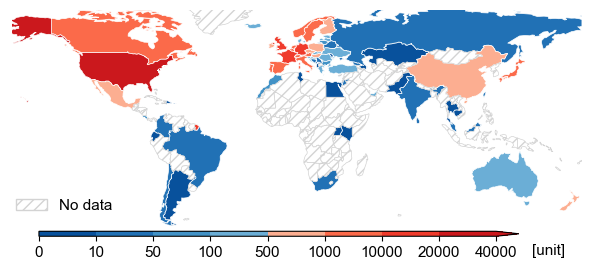

In [134]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

# Prepare and merge data
world_merged = world.merge(df_cs, how='left', left_on='NAME', right_on='country')

# --- 1. Define custom bounds ---
bounds = [0, 10, 50, 100, 500, 1000, 10000, 20000, 40000]  # cover full range
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=8)

# --- 2. Define custom colors (10 categories) ---
custom_colors = [
    "#08519c", "#2171b5", "#4292c6", "#6baed6",
    "#fcae91", "#fb6a4a", "#ef3b2c", "#cb181d"
]
cmap = mcolors.ListedColormap(custom_colors)

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
world_merged.plot(
    column='station_count',
    cmap=cmap,
    norm=norm,
    linewidth=0.5,
    ax=ax,
    edgecolor='white',
    legend=False,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///"
    }
)

# Remove axes
ax.set_axis_off()
ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)

# --- 4. Add discrete colorbar ---
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.07, 0.27, 0.8, 0.01])  # [left, bottom, width, height] in figure coordinates
cbar = fig.colorbar(
    sm,
    cax=cbar_ax,  # use the custom axes
    orientation="horizontal",
    fraction=0.1,
    pad=0.0,
    shrink=0.95, 
    aspect=80, 
    extend='max',
    boundaries=bounds,
    ticks=[0, 10, 50, 100, 500, 1000, 10000, 20000, 40000]
)

# Format ticks with TWh
tick_labels = ["0", "10", "50", "100", "500", "1000", "10000", "20000", "40000"]
cbar.ax.set_xticklabels(tick_labels, fontsize=11)

# --- 5. Add "No data" patch to the left of colorbar ---
no_data_patch = Patch(facecolor="white", edgecolor="lightgrey", hatch="///", label="No data")
cbar.ax.legend(
    handles=[no_data_patch],
    loc="lower left",
    bbox_to_anchor=(-0.08, 2.0),
    frameon=False,
    fontsize=11
)

# Add custom text "[%]" below the colorbar
fig.text(
    0.92,         # x position (0 to 1, relative to figure width)
    0.242,         # y position (0 to 1, relative to figure height)
    "[unit]",      # text to display
    ha='center', # horizontal alignment
    va='center', # vertical alignment
    fontsize=11, 
    fontname='Arial', 
)

plt.tight_layout()
plt.savefig('cs_deployment.pdf', format='pdf', bbox_inches='tight')
plt.show()